### 1. Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import sys
import os
import subprocess
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from sae.tools.experiment_utils import get_experiment_dir, get_metrics_dir, get_report_name
from sae.tools.naming_utils import get_checkpoint_dir, get_model_name, get_extras_id

project_root = Path('../../..').resolve()
sys.path.insert(0, str(project_root))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 5060
Memoria: 8.55 GB


In [2]:
# Configuración para visualización en PDF
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)
np.set_printoptions(linewidth=100, edgeitems=3)

os.environ['COLUMNS'] = '100'

print(" Configuración para PDF lista")

 Configuración para PDF lista


In [3]:
NAMING_META = {
    'variante': 'topk',              
    'tecnica': 'batch-topk',               
    'capa': 6,                      
    'juegos': 5000,                   
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\sae-othello-gpt',
    'experiment_base_path': os.path.abspath('../../../experiments'),
    'extras': {
        'expansion': 16,   
        'k': 81,           
        'epochs': 1000,
        'patience': 20,
        'batch_size_tokens': 1024,
    }
}

print('\n Metadata de naming:')
for key, value in NAMING_META.items():
    print(f'  {key}: {value}')


 Metadata de naming:
  variante: topk
  tecnica: batch-topk
  capa: 6
  juegos: 5000
  base_path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt
  experiment_base_path: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments
  extras: {'expansion': 16, 'k': 81, 'epochs': 1000, 'patience': 20, 'batch_size_tokens': 1024}


In [4]:
class BatchTopKSAE(nn.Module):
    def __init__(self, d_in: int, d_sae: int, k: int, k_aux: int = 512):
        super().__init__()
        self.d_in  = d_in
        self.d_sae = d_sae
        self.k     = k
        self.k_aux = k_aux

        self.W_enc = nn.Parameter(torch.empty(d_in, d_sae))
        self.W_dec = nn.Parameter(torch.empty(d_sae, d_in))
        self.b_dec = nn.Parameter(torch.zeros(d_in))

        nn.init.kaiming_uniform_(self.W_enc)
        nn.init.kaiming_uniform_(self.W_dec)
        self.W_dec.data = self.W_dec.data / self.W_dec.data.norm(dim=-1, keepdim=True)
        self.register_buffer('num_batches_not_active', torch.zeros(d_sae))

    def encode(self, x: torch.Tensor, threshold=None) -> torch.Tensor:
        x_norm, _, _ = self.preprocess_input(x)
        x_cent   = x_norm - self.b_dec
        pre_acts = F.relu(x_cent @ self.W_enc)
        return self._topk_activation(pre_acts, threshold=threshold)

    def _topk_activation(self, x: torch.Tensor, threshold=None) -> torch.Tensor:
        if threshold is None:
            acts_topk = torch.topk(x.flatten(), self.k * x.shape[0], dim=-1)
            return (
                torch.zeros_like(x.flatten())
                .scatter(-1, acts_topk.indices, acts_topk.values)
                .reshape(x.shape)
            )
        return torch.where(x > threshold, x, torch.zeros_like(x))

    def decode(self, hidden: torch.Tensor) -> torch.Tensor:
        return hidden @ self.W_dec + self.b_dec

    def preprocess_input(self, x: torch.Tensor):
        x_mean = x.mean(dim=-1, keepdim=True)
        x = x - x_mean
        x_std = x.std(dim=-1, keepdim=True)
        x = x / (x_std + 1e-5)
        return x, x_mean, x_std

    def postprocess_output(self, x_reconstruct, x_mean, x_std):
        return x_reconstruct * x_std + x_mean

    def forward(self, x: torch.Tensor, threshold=None):
        x_norm, x_mean, x_std = self.preprocess_input(x)
        x_cent   = x_norm - self.b_dec
        pre_acts = F.relu(x_cent @ self.W_enc)
        hidden   = self._topk_activation(pre_acts, threshold=threshold)
        recon    = self.postprocess_output(self.decode(hidden), x_mean, x_std)
        return recon, hidden, pre_acts

print("BatchTopKSAE definida")

BatchTopKSAE definida


### 2. Cargar Datos

In [5]:
# Cargar activaciones
activations_path = project_root / "activations" / "data" / "layer6_2000games.npy"
activations = np.load(activations_path)

print(f"Activaciones del modelo:")
print(f"  Shape: {activations.shape}")
print(f"  Memoria: {activations.nbytes / (1024**2):.2f} MB")

Activaciones del modelo:
  Shape: (118000, 512)
  Memoria: 230.47 MB


In [6]:
# Cargar ground truth de BSPs
bsp_gt_path = project_root / "metrics" / "02_data" / "bsp_ground_truth_2000games.npy"
bsp_names_path = project_root / "metrics" / "02_data" / "bsp_ground_truth_2000games.names.npy"

bsp_ground_truth = np.load(bsp_gt_path)
bsp_names = np.load(bsp_names_path, allow_pickle=True)

print(f"\nGround truth BSPs:")
print(f"  Shape: {bsp_ground_truth.shape}")
print(f"  Total BSPs: {len(bsp_names)}")


Ground truth BSPs:
  Shape: (118000, 326)
  Total BSPs: 326


### 3. Cargar SAE y Extraer Features

In [7]:
# Configuración del SAE
input_dim = 512
hidden_dim = 8192

# Construir ruta del modelo usando naming_utils
checkpoint_dir = get_checkpoint_dir(
    NAMING_META['base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos']
)
extras_id = get_extras_id(checkpoint_dir, NAMING_META['extras']) if NAMING_META.get('extras') else None

model_filename = get_model_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    'best',
    extras_id=extras_id
)
model_path = checkpoint_dir / model_filename

# Cargar modelo BatchTopK
sae = BatchTopKSAE(d_in=input_dim, d_sae=hidden_dim, k=NAMING_META['extras']['k']).to(device)

checkpoint = torch.load(model_path, map_location=device, weights_only=False)
sae.load_state_dict(checkpoint['model_state_dict'])
sae.eval()

print(f"SAE cargado:")
print(f"  Path: {model_path}")
print(f"  Input: {input_dim}, Hidden: {hidden_dim}, k: {NAMING_META['extras']['k']}")
print(f"  Expansion: {hidden_dim/input_dim}x")

SAE cargado:
  Path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_topk\sae_batch-topk_topk\5000games\sae_topk_batch-topk_l6_5000g_ex2_best.pt
  Input: 512, Hidden: 8192, k: 81
  Expansion: 16.0x


In [8]:
# Extraer features del SAE en GPU
print("Extrayendo features del SAE...")
activations_tensor = torch.from_numpy(activations).float().to(device)

# Estimar threshold con mini-batch
with torch.no_grad():
    sample = activations_tensor[:4096]
    x_s, _, _ = sae.preprocess_input(sample)
    pre_s = F.relu((x_s - sae.b_dec) @ sae.W_enc)
    threshold = torch.topk(pre_s.flatten(), sae.k * 4096).values.min().item()
print(f"Threshold estimado: {threshold:.6f}")

# Encoding completo con operación in-place
with torch.no_grad():
    x_norm, _, _ = sae.preprocess_input(activations_tensor)
    x_cent = x_norm - sae.b_dec
    pre_acts = F.relu(x_cent @ sae.W_enc)
    pre_acts.mul_(pre_acts > threshold)
    sae_features = pre_acts

del activations_tensor, x_norm, x_cent
torch.cuda.empty_cache()

print(f"\nFeatures SAE:")
print(f"  Shape: {sae_features.shape}")
print(f"  Device: {sae_features.device}")
print(f"  Sparsity: {(sae_features == 0).float().mean():.2%}")
print(f"  Activaciones promedio: {(sae_features > 0).sum(dim=1).float().mean():.1f}")

Extrayendo features del SAE...
Threshold estimado: 0.719861

Features SAE:
  Shape: torch.Size([118000, 8192])
  Device: cuda:0
  Sparsity: 99.02%
  Activaciones promedio: 80.6


### 4. Split Train/Test y Filtrar BSPs de Piezas

In [9]:
# Split 50/50: 
n_moves = 59
n_games = 2000  # número de partidas para prueba de métricas
train_games = n_games // 2  
split_idx = train_games * n_moves  

sae_features_train = sae_features[:split_idx]
sae_features_test  = sae_features[split_idx:]

print(f"Total partidas: {n_games}")
print(f"Train: {train_games} partidas ({split_idx} activaciones)")
print(f"Test:  {n_games - train_games} partidas ({len(activations) - split_idx} activaciones)")
print(f"Train set: {sae_features_train.shape}")
print(f"Test set:  {sae_features_test.shape}")

Total partidas: 2000
Train: 1000 partidas (59000 activaciones)
Test:  1000 partidas (59000 activaciones)
Train set: torch.Size([59000, 8192])
Test set:  torch.Size([59000, 8192])


In [10]:
# =============================================
# CONFIGURACIÓN DE FILTRADO DE BSPs
# =============================================
USE_PLAYER   = False  # BSPs perspectiva del jugador (1 y 2)
USE_ABSOLUTE = True   # BSPs absolutas negro/blanco (B y W)
USE_STRATEGIC = False  # BSPs especiales (BSP_)

bsp_pieces_indices = []
bsp_pieces_names = []

for i, name in enumerate(bsp_names):
    include = False
    if USE_PLAYER and len(name) == 6 and name.startswith('BSP') and (name.endswith('1') or name.endswith('2')):
        include = True
    if USE_ABSOLUTE and (name.endswith('B') or name.endswith('W')):
        include = True
    if USE_STRATEGIC and name.startswith('BSP_'):
        include = True
    if include:
        bsp_pieces_indices.append(i)
        bsp_pieces_names.append(name)

bsp_pieces_indices = np.array(bsp_pieces_indices)

# Para reconstruction necesitas split train/test
bsp_gt_train_pieces = torch.from_numpy(bsp_ground_truth[:split_idx, bsp_pieces_indices]).bool().to(device)
bsp_gt_test_pieces  = torch.from_numpy(bsp_ground_truth[split_idx:, bsp_pieces_indices]).bool().to(device)

# Convertir a tensor en GPU
# Identificador del filtrado (para naming de archivos de salida)
parts = []
if USE_PLAYER: parts.append("player")
if USE_ABSOLUTE: parts.append("absolute")
if USE_STRATEGIC: parts.append("strategic")
filter_suffix = "_".join(parts) if parts else "none"

print(f"BSPs seleccionadas para Reconstruction:")
print(f"  Player: {USE_PLAYER} | Absolute: {USE_ABSOLUTE} | Strategic: {USE_STRATEGIC}")
print(f"  Total: {len(bsp_pieces_indices)}")
print(f"  Train shape: {bsp_gt_train_pieces.shape}")
print(f"  Test shape:  {bsp_gt_test_pieces.shape}")
print(f"  Device: {bsp_gt_train_pieces.device}")
print(f"  Primeras 5: {', '.join(bsp_pieces_names[:5])}")
print(f"  Últimas 5: {', '.join(bsp_pieces_names[-5:])}")
print(f"  Filter suffix: {filter_suffix}")


BSPs seleccionadas para Reconstruction:
  Player: False | Absolute: True | Strategic: False
  Total: 128
  Train shape: torch.Size([59000, 128])
  Test shape:  torch.Size([59000, 128])
  Device: cuda:0
  Primeras 5: BSPA1B, BSPA1W, BSPA2B, BSPA2W, BSPA3B
  Últimas 5: BSPH6W, BSPH7B, BSPH7W, BSPH8B, BSPH8W
  Filter suffix: absolute


### 5. Funciones GPU-Optimizadas

In [11]:
def fast_precision_score_gpu(y_true, y_pred, eps=1e-8):
    """
    Precisión vectorizada en GPU.
    
    Args:
        y_true: Tensor (n_positions,) booleano
        y_pred: Tensor (n_positions, n_candidates) booleano
    
    Returns:
        precision_scores: Tensor (n_candidates,)
    """
    y_true_expanded = y_true.unsqueeze(1)
    
    tp = (y_true_expanded & y_pred).sum(dim=0).float()
    fp = (~y_true_expanded & y_pred).sum(dim=0).float()
    
    precision = tp / (tp + fp + eps)
    
    return precision


def fast_f1_score_gpu(y_true, y_pred, eps=1e-8):
    """
    F1 score vectorizado en GPU.
    
    Args:
        y_true: Tensor (n_positions,) booleano
        y_pred: Tensor (n_positions,) booleano  
    
    Returns:
        f1: Float
    """
    tp = (y_true & y_pred).sum().float()
    fp = (~y_true & y_pred).sum().float()
    fn = (y_true & ~y_pred).sum().float()
    
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    
    return f1.item()

print(" Funciones GPU definidas")

 Funciones GPU definidas


### 6. Fase 1: Identificar Features de Alta Precisión (GPU)

Para cada BSP, encontrar features con precisión ≥ 0.95 en el train set.

In [12]:
def identify_high_precision_features_gpu(
    sae_features_train,
    bsp_gt_train,
    f_max,
    precision_threshold=0.95,
    significance_threshold=1,
    thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    feature_batch_size=512,
    verbose=True
):
    """
    Para cada (threshold t, feature f, BSP b): determina si f es clasificador
    de alta precisión para b al threshold t.

    Criterios (igual que implementación oficial):
        - precision(f, b, t) >= precision_threshold   (default 0.95)
        - on_count(f, t)     >= significance_threshold (default 10)

    Args:
        sae_features_train:    Tensor (P, n_features) GPU
        bsp_gt_train:          Tensor (P, n_bsps) GPU, bool
        f_max:                 Tensor (n_features,) GPU — calculado FUERA para
                               garantizar identidad exacta con Fase 2
        precision_threshold:   float, default 0.95
        significance_threshold: int, mín. activaciones requeridas (default 10)
        thresholds:            lista de fracciones t ∈ [0, 1)
        feature_batch_size:    int, features por mini-batch interno

    Returns:
        hp_mask_TFB:            BoolTensor (T, n_active, n_bsps)
        active_feature_indices: LongTensor (n_active,)
    """
    n_positions, n_features = sae_features_train.shape
    n_bsps = bsp_gt_train.shape[1]
    device = sae_features_train.device

    thresholds_T = torch.tensor(thresholds, device=device)
    n_thresholds = len(thresholds_T)

    # Features vivas (f_max > 0)
    active_feature_indices = (f_max > 0).nonzero(as_tuple=True)[0]
    n_active = len(active_feature_indices)

    if verbose:
        print("=" * 60)
        print("FASE 1: IDENTIFICAR FEATURES DE ALTA PRECISIÓN")
        print("=" * 60)
        print(f"Precision threshold:     {precision_threshold}")
        print(f"Significance threshold:  >= {significance_threshold} activaciones")
        print(f"Features activas:        {n_active}/{n_features} ({n_active/n_features*100:.1f}%)")
        print(f"BSPs:                    {n_bsps}")
        print(f"Thresholds:              {thresholds}")
        print("=" * 60)

    # Thresholds absolutos: thresh_TF[t, f] = t * f_max[f]
    active_f_max  = f_max[active_feature_indices]           # (n_active,)
    thresholds_TF = thresholds_T[:, None] * active_f_max   # (T, n_active)

    # Acumuladores sobre todo el train set
    on_count_TF  = torch.zeros(n_thresholds, n_active, device=device)
    tp_count_TFB = torch.zeros(n_thresholds, n_active, n_bsps, device=device)

    bsp_float_PB = bsp_gt_train.float()  # (P, B)

    n_iters = (n_active + feature_batch_size - 1) // feature_batch_size

    for fi in tqdm(range(n_iters), desc="Fase 1"):
        f_start = fi * feature_batch_size
        f_end   = min(f_start + feature_batch_size, n_active)

        global_idx = active_feature_indices[f_start:f_end]
        acts_PF    = sae_features_train[:, global_idx]     # (P, bs)
        thresh_TF  = thresholds_TF[:, f_start:f_end]      # (T, bs)

        # active_TFP[t, f, p] = True si acts[p,f] > thresh[t,f]
        active_TFP = acts_PF.T.unsqueeze(0) > thresh_TF.unsqueeze(2)  # (T, bs, P)

        # Conteo de activaciones por (threshold, feature)
        on_count_TF[:, f_start:f_end] += active_TFP.sum(dim=2).float()

        # True positives: f activa Y BSP verdadera
        # tp[t, f, b] = Σ_p active[t,f,p] * bsp[p,b]
        tp_count_TFB[:, f_start:f_end, :] += torch.einsum(
            'tfp,pb->tfb', active_TFP.float(), bsp_float_PB
        )

    # Precisión: tp / on_count
    eps = 1e-8
    precision_TFB = tp_count_TFB / (on_count_TF.unsqueeze(2) + eps)  # (T, F, B)

    # Máscara: alta precisión AND significancia suficiente
    sig_mask_TF1 = (on_count_TF >= significance_threshold).unsqueeze(2)  # (T, F, 1)
    hp_mask_TFB  = (precision_TFB >= precision_threshold) & sig_mask_TF1  # (T, F, B)

    if verbose:
        hp_per_t = hp_mask_TFB.sum(dim=(1, 2))  # (T,)
        hp_per_b = hp_mask_TFB.sum(dim=1)        # (T, B)
        best_t   = hp_per_t.argmax().item()
        print(f"\nPares (feature, BSP) de alta precisión por threshold:")
        for i, t in enumerate(thresholds):
            marker = " ← más pares" if i == best_t else ""
            print(f"  t={t:.1f}: {hp_per_t[i].item():5d} pares{marker}")
        print(f"\nFeatures HP por BSP en t={thresholds[best_t]:.1f}:")
        print(f"  Media:             {hp_per_b[best_t].float().mean():.1f}")
        print(f"  Máx:               {hp_per_b[best_t].max().item()}")
        print(f"  BSPs sin features: {(hp_per_b[best_t] == 0).sum().item()}")

    return hp_mask_TFB, active_feature_indices

print("✓ Fase 1 rediseñada: umbral de significancia (≥10) + estructura (T, F, B)")

✓ Fase 1 rediseñada: umbral de significancia (≥10) + estructura (T, F, B)


In [13]:
THRESHOLDS = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# f_max calculado UNA SOLA VEZ aquí — se pasa a Fase 1 y Fase 2
f_max = sae_features_train.max(dim=0)[0]  # (n_features,)
print(f"f_max calculado: {(f_max > 0).sum().item()} features activas de {f_max.shape[0]}")

start_time = time.time()

hp_mask_TFB, active_feature_indices = identify_high_precision_features_gpu(
    sae_features_train,
    bsp_gt_train_pieces,
    f_max,
    precision_threshold=0.95,
    significance_threshold=1,
    thresholds=THRESHOLDS,
    feature_batch_size=512,
    verbose=True
)

phase1_time = time.time() - start_time

print(f"\nTiempo Fase 1: {phase1_time:.2f} seg")
print(f"hp_mask_TFB shape: {hp_mask_TFB.shape}  (T, n_active, n_bsps)")

f_max calculado: 8192 features activas de 8192
FASE 1: IDENTIFICAR FEATURES DE ALTA PRECISIÓN
Precision threshold:     0.95
Significance threshold:  >= 1 activaciones
Features activas:        8192/8192 (100.0%)
BSPs:                    128
Thresholds:              [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


Fase 1: 100%|██████████| 16/16 [00:00<00:00, 1452.48it/s]



Pares (feature, BSP) de alta precisión por threshold:
  t=0.0:   255 pares
  t=0.1:   286 pares
  t=0.2:   944 pares
  t=0.3:  1925 pares
  t=0.4:  3074 pares
  t=0.5:  4864 pares
  t=0.6:  8601 pares
  t=0.7: 20403 pares
  t=0.8: 52006 pares
  t=0.9: 118425 pares ← más pares

Features HP por BSP en t=0.9:
  Media:             925.2
  Máx:               3093
  BSPs sin features: 0

Tiempo Fase 1: 0.87 seg
hp_mask_TFB shape: torch.Size([10, 8192, 128])  (T, n_active, n_bsps)


### 7. Fase 2: Reconstruir Tableros en Test Set (GPU)

In [14]:
def reconstruct_boards_gpu(
    sae_features_test,
    bsp_gt_test,
    hp_mask_TFB,
    active_feature_indices,
    f_max,
    thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    verbose=True
):
    """
    Fase 2: barrido simultáneo de thresholds T → toma el mejor F1.

    Para cada threshold t:
      1. Binarizar features de test: active[p, f] = acts[p, f] > t * f_max[f]
      2. Predicción por (posición, BSP):
             predict[p, b] = OR_f ( active[p,f] AND hp_mask[t, f, b] )
             implementado como: (active_PF @ hp_FB) > 0
      3. F1 global micro-averaged (acumula TP/FP/FN sobre todas las posiciones y BSPs)
    
    Retorna el max F1 sobre todos los thresholds (Eq. 5 del paper: max_t).

    Args:
        sae_features_test:      Tensor (P, n_features) GPU
        bsp_gt_test:            Tensor (P, n_bsps) GPU, bool
        hp_mask_TFB:            BoolTensor (T, n_active, n_bsps) de Fase 1
        active_feature_indices: LongTensor (n_active,) de Fase 1
        f_max:                  Tensor (n_features,) GPU — MISMO objeto que Fase 1
        thresholds:             lista de fracciones (debe coincidir con Fase 1)

    Returns:
        best_f1:          float, max F1 sobre thresholds
        best_threshold:   float, threshold óptimo
        f1_per_threshold: np.array (T,), F1 por threshold
    """
    device = sae_features_test.device
    n_thresholds = len(thresholds)
    thresholds_T = torch.tensor(thresholds, device=device)

    # Activaciones del test solo para features activas
    test_active_PF = sae_features_test[:, active_feature_indices]  # (P, n_active)
    active_f_max   = f_max[active_feature_indices]                  # (n_active,)

    gt_PB = bsp_gt_test.bool()  # (P, B)
    eps   = 1e-8

    f1_scores   = torch.zeros(n_thresholds, device=device)
    precision_T = torch.zeros(n_thresholds, device=device)
    recall_T    = torch.zeros(n_thresholds, device=device)

    if verbose:
        print("=" * 60)
        print("FASE 2: RECONSTRUCCIÓN — BARRIDO DE THRESHOLDS")
        print("=" * 60)
        print(f"{'t':>5}  {'F1':>8}  {'P':>8}  {'R':>8}  {'TP':>8}  {'FP':>8}  {'FN':>8}")
        print("-" * 60)

    for t_idx in range(n_thresholds):
        t = thresholds[t_idx]

        # Threshold absoluto por feature: t * f_max[f]
        abs_thresh_F = thresholds_T[t_idx] * active_f_max  # (n_active,)

        # Binarizar features en test
        active_PF = test_active_PF > abs_thresh_F.unsqueeze(0)  # (P, n_active)

        # predict[p, b] = any( active[p,f] AND hp[t,f,b] )
        # = (active_PF.float() @ hp_mask[t].float()) > 0
        hp_FB          = hp_mask_TFB[t_idx].float()              # (n_active, B)
        predictions_PB = (active_PF.float() @ hp_FB) > 0         # (P, B)

        # Métricas globales micro-averaged
        tp = (predictions_PB &  gt_PB).sum().float()
        fp = (predictions_PB & ~gt_PB).sum().float()
        fn = (~predictions_PB & gt_PB).sum().float()

        p  = tp / (tp + fp + eps)
        r  = tp / (tp + fn + eps)
        f1 = 2 * p * r / (p + r + eps)

        f1_scores[t_idx]   = f1
        precision_T[t_idx] = p
        recall_T[t_idx]    = r

        if verbose:
            print(f"{t:>5.1f}  {f1.item():>8.4f}  {p.item():>8.4f}  {r.item():>8.4f}"
                  f"  {tp.item():>8.0f}  {fp.item():>8.0f}  {fn.item():>8.0f}")

    best_idx       = f1_scores.argmax().item()
    best_f1        = f1_scores[best_idx].item()
    best_threshold = thresholds[best_idx]

    if verbose:
        print("=" * 60)
        print(f"Mejor threshold: t={best_threshold:.1f}")
        print(f"Reconstruction Score (max_t F1): {best_f1:.4f}")
        print("=" * 60)

    return best_f1, best_threshold, f1_scores.cpu().numpy()

print("✓ Fase 2 rediseñada: barrido T simultáneo + F1 global micro-averaged + max_t")

✓ Fase 2 rediseñada: barrido T simultáneo + F1 global micro-averaged + max_t


In [15]:
start_time = time.time()

reconstruction_score, best_threshold, f1_per_threshold = reconstruct_boards_gpu(
    sae_features_test,
    bsp_gt_test_pieces,
    hp_mask_TFB,
    active_feature_indices,
    f_max,           # mismo tensor calculado antes de Fase 1
    thresholds=THRESHOLDS,
    verbose=True
)

phase2_time = time.time() - start_time
total_time  = phase1_time + phase2_time

print(f"\nTiempo Fase 2: {phase2_time:.2f} seg")
print(f"Tiempo total:  {total_time:.2f} seg ({total_time/60:.2f} min)")

FASE 2: RECONSTRUCCIÓN — BARRIDO DE THRESHOLDS
    t        F1         P         R        TP        FP        FN
------------------------------------------------------------
  0.0    0.0140    0.9345    0.0071     14177       994   1991823
  0.1    0.0150    0.9310    0.0075     15133      1121   1990867
  0.2    0.0268    0.9338    0.0136     27262      1934   1978738
  0.3    0.0350    0.9412    0.0178     35739      2234   1970261
  0.4    0.0385    0.9407    0.0197     39455      2489   1966545
  0.5    0.0416    0.9235    0.0213     42650      3533   1963350
  0.6    0.0445    0.8419    0.0229     45886      8618   1960114
  0.7    0.0526    0.6973    0.0273     54840     23804   1951160
  0.8    0.0681    0.5521    0.0363     72751     59009   1933249
  0.9    0.0862    0.4691    0.0475     95198    107722   1910802
Mejor threshold: t=0.9
Reconstruction Score (max_t F1): 0.0862

Tiempo Fase 2: 3.91 seg
Tiempo total:  4.78 seg (0.08 min)


### 8. Análisis de Resultados

BARRIDO DE THRESHOLDS — F1 POR THRESHOLD
t=0.0: F1=0.0140
t=0.1: F1=0.0150
t=0.2: F1=0.0268
t=0.3: F1=0.0350
t=0.4: F1=0.0385
t=0.5: F1=0.0416
t=0.6: F1=0.0445
t=0.7: F1=0.0526
t=0.8: F1=0.0681
t=0.9: F1=0.0862 ← MEJOR


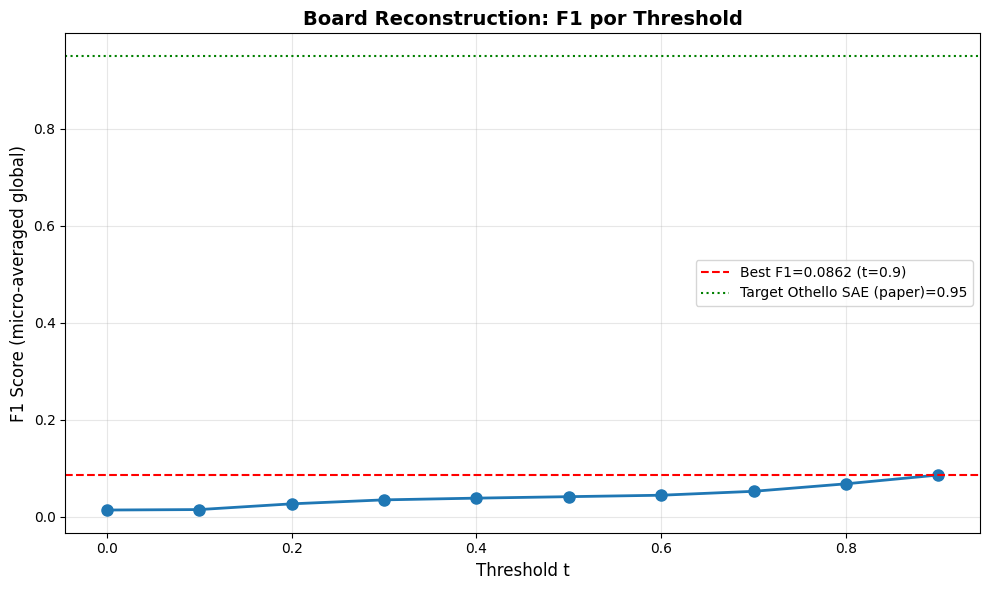


✓ Threshold óptimo: t=0.9
✓ Reconstruction Score: 0.0862


In [16]:
print("=" * 60)
print("BARRIDO DE THRESHOLDS — F1 POR THRESHOLD")
print("=" * 60)
for i, (t, f1) in enumerate(zip(THRESHOLDS, f1_per_threshold)):
    marker = " ← MEJOR" if i == f1_per_threshold.argmax() else ""
    print(f"t={t:.1f}: F1={f1:.4f}{marker}")
print("=" * 60)

plt.figure(figsize=(10, 6))
plt.plot(THRESHOLDS, f1_per_threshold, marker='o', linewidth=2, markersize=8)
plt.axhline(y=reconstruction_score, color='r', linestyle='--',
            label=f'Best F1={reconstruction_score:.4f} (t={best_threshold:.1f})')
plt.axhline(y=0.95, color='g', linestyle=':', label='Target Othello SAE (paper)=0.95')
plt.xlabel('Threshold t', fontsize=12)
plt.ylabel('F1 Score (micro-averaged global)', fontsize=12)
plt.title('Board Reconstruction: F1 por Threshold', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n✓ Threshold óptimo: t={best_threshold:.1f}")
print(f"✓ Reconstruction Score: {reconstruction_score:.4f}")

In [17]:
# Estadísticas sobre features de alta precisión por BSP
hp_per_bsp = hp_mask_TFB.sum(dim=1)  # (T, n_bsps)
best_t_idx = torch.tensor(f1_per_threshold).argmax().item()
n_features_per_bsp = hp_per_bsp[best_t_idx].cpu().numpy()

print("="*60)
print("ESTADÍSTICAS - FEATURES POR BSP")
print("="*60)
print(f"Total BSPs: {len(n_features_per_bsp)}")
print(f"Features promedio por BSP: {np.mean(n_features_per_bsp):.1f}")
print(f"Features mediana por BSP: {np.median(n_features_per_bsp):.1f}")
print(f"BSPs con 0 features: {np.sum(n_features_per_bsp == 0)}")
print(f"BSPs con 1+ features: {np.sum(n_features_per_bsp > 0)}")
print(f"BSPs con 5+ features: {np.sum(n_features_per_bsp >= 5)}")
print(f"BSPs con 10+ features: {np.sum(n_features_per_bsp >= 10)}")
print(f"Max features en una BSP: {np.max(n_features_per_bsp)}")
print("="*60)

ESTADÍSTICAS - FEATURES POR BSP
Total BSPs: 128
Features promedio por BSP: 925.2
Features mediana por BSP: 741.0
BSPs con 0 features: 0
BSPs con 1+ features: 128
BSPs con 5+ features: 128
BSPs con 10+ features: 128
Max features en una BSP: 3093


### 9. Guardar Resultados

In [18]:
results = {
    'reconstruction_score': reconstruction_score,
    'best_threshold': best_threshold,
    'f1_per_threshold': f1_per_threshold,
    'thresholds': np.array(THRESHOLDS),
    'phase1_time_seconds': phase1_time,
    'phase2_time_seconds': phase2_time,
    'total_time_seconds': total_time,
    'bsp_names': bsp_pieces_names,
}

metrics_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)
output_path = metrics_dir / f"reconstruction_results_{filter_suffix}.npz"
np.savez(output_path, **results)

print(f"✓ Resultados guardados en: {output_path}")
print(f"\nContenido:")
print(f"  reconstruction_score: {reconstruction_score:.4f}")
print(f"  best_threshold:       {best_threshold:.1f}")
print(f"  f1_per_threshold:     {f1_per_threshold}")

# Comparación con el paper
print()
print("=" * 60)
print("COMPARACIÓN CON PAPER (Karvonen et al., NeurIPS 2024)")
print("=" * 60)
print(f"{'Modelo':<25} {'Reconstruction':>14}")
print("-" * 40)
print(f"{'SAE trained (paper)':<25} {'0.95':>14}  ← Objetivo Othello")
print(f"{'Nuestro SAE':<25} {reconstruction_score:>14.4f}  ← Resultado")
print("=" * 60)

if reconstruction_score >= 0.90:
    print("\n✓ Excelente: Muy cercano al objetivo del paper")
elif reconstruction_score >= 0.50:
    print("\n~ Moderado: Por encima de random, revisar SAE")
else:
    print("\n✗ Bajo: Revisar entrenamiento del SAE o calidad de las activaciones")

✓ Resultados guardados en: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\5000games\ex2\metrics\reconstruction_results_absolute.npz

Contenido:
  reconstruction_score: 0.0862
  best_threshold:       0.9
  f1_per_threshold:     [0.0140285  0.01496647 0.02679054 0.03497013 0.03853133 0.0415655  0.04453862 0.0526133  0.06806283
 0.08619416]

COMPARACIÓN CON PAPER (Karvonen et al., NeurIPS 2024)
Modelo                    Reconstruction
----------------------------------------
SAE trained (paper)                 0.95  ← Objetivo Othello
Nuestro SAE                       0.0862  ← Resultado

✗ Bajo: Revisar entrenamiento del SAE o calidad de las activaciones


### 10. Generar PDF con Quarto

In [20]:
output_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

pdf_name = get_report_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    f'reconstruction_{filter_suffix}',
    extras_id=extras_id
)

notebook_name = 'reconstruction_sae_batchtopk.ipynb'
output_path = output_dir / pdf_name

print(f' Generando PDF con Quarto...')
print(f' Archivo de salida: {output_path}')

result = subprocess.run(
    f'quarto render {notebook_name} --to pdf --output-dir "{output_dir}" --output {pdf_name}',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f' PDF generado exitosamente: {output_path}')
else:
    print(f' Error al generar PDF:')
    print(result.stderr)

 Generando PDF con Quarto...
 Archivo de salida: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\5000games\ex2\metrics\sae_topk_batch-topk_l6_5000g_ex2_reconstruction_absolute.pdf
 PDF generado exitosamente: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_topk\sae_batch-topk_topk\5000games\ex2\metrics\sae_topk_batch-topk_l6_5000g_ex2_reconstruction_absolute.pdf
